# Real Data Experiments of NeurIPS 2023 Paper

Reproduces Table 2 and Figure 3 of the NeurIPS 2023 paper comparing

1. EM - Bayesian Ridge Regression with maximisisation of the marginal $(\sigma^2, \tau^2)$ posterior via EM algorithm with half-Cauchy prior on $\tau$ (`RidgeEM(t2=False)`)
2. CVFix - LOOCV Ridge regression with 100 logarithmically spaced candidates for $\lambda$ (`RidgeLOOCV(alphas=np.logspace(-10, 10, 100, base=10)`)
3. CVGlm - LOOCV Ridge regression with 100 candidates chosen according to the GLMNet heuristic (`RidgeLOOCV(alphas=100)`)

in terms of the $R^2$-vales they achieve on the `NEURIPS2023` problem collection.

All experiments take substantial time and are therefore not run during integration testing.

## No Interaction Variables

Expected computation time on Apple M4 Pro about 20 minutes.

In [1]:
import numpy as np
from fastridge import RidgeEM, RidgeLOOCV
from experiments import EmpiricalDataExperiment
from problems import NEURIPS2023
from data import DATASETS

# estimator indices: 0=EM, 1=CV_fix, 2=CV_glm
estimators = [
    RidgeEM(t2=False),
    RidgeLOOCV(alphas=np.logspace(-10, 10, 100, base=10)),
    RidgeLOOCV(alphas=100),
]
est_names = ['EM', 'CV_fix', 'CV_glm']

problems_d1 = sorted(NEURIPS2023, key=lambda p: DATASETS[p.dataset]['n'])
exp_d1 = EmpiricalDataExperiment(
    problems_d1, estimators, n_iterations=100, seed=123,
    est_names=est_names, verbose=True).run()
print()

ribo (n=71, p=4088)....................................................................................................
eye (n=120, p=200)....................................................................................................
automobile (n=159, p=51)....................................................................................................
yacht (n=308, p=6)....................................................................................................
autompg (n=392, p=7)....................................................................................................
real_estate (n=414, p=6)....................................................................................................
diabetes (n=442, p=10)....................................................................................................
facebook (n=499, p=17)....................................................................................................
boston (n=506, p=13).....

In [15]:
import pandas as pd

rows_d1 = []
for i, problem in enumerate(exp_d1.problems):
    em_time  = np.nanmean(exp_d1.fitting_time_[:, i, 0, 0])
    cv_time  = (np.nanmean(exp_d1.fitting_time_[:, i, 0, 1])
               + np.nanmean(exp_d1.fitting_time_[:, i, 0, 2])) / 2
    row = {'dataset': problem.dataset, 'target': problem.target, 'd': 1}
    for j, name in enumerate(exp_d1.est_names):
        row[name] = np.nanmean(exp_d1.prediction_r2_[:, i, 0, j])
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = np.nanmean(exp_d1.number_of_features_[:, i, 0, 0])
    row['n_train']        = int(exp_d1.ns[i, 0])
    row['n:p']            = int(exp_d1.ns[i, 0]) / np.nanmean(exp_d1.number_of_features_[:, i, 0, 0])
    rows_d1.append(row)
df_d1 = pd.DataFrame(rows_d1).sort_values(['n_train', 'dataset', 'target'], ascending=[False, True, True]).round(2)
df_d1

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
22,twitter,V78,1,0.93,0.93,0.93,4.63,77.00,408275,5302.27
21,ct_slices,reference,1,0.86,0.86,0.86,3.54,379.73,37450,98.62
20,blog,V281,1,0.35,0.35,0.35,3.76,275.77,36677,133.00
19,tomshw,V97,1,0.96,0.96,0.96,3.77,96.00,19725,205.47
17,naval_propulsion,GT_compressor_decay,1,0.84,0.84,0.84,6.77,15.00,8353,556.87
18,naval_propulsion,GT_turbine_decay,1,0.91,0.91,0.91,6.69,15.00,8353,556.87
15,parkinsons,motor_UPDRS,1,0.15,0.15,0.15,5.71,19.00,4112,216.42
16,parkinsons,total_UPDRS,1,0.17,0.17,0.17,5.61,19.00,4112,216.42
14,abalone,Rings,1,0.53,0.53,0.53,8.72,9.00,2923,324.78
13,crime,ViolentCrimesPerPop,1,0.66,0.66,0.66,2.50,99.00,1395,14.09


## 2nd Order Terms

Expected computation time on Apple M4 Pro: 63 minutes

In [3]:
from problems import NEURIPS2023_D2

problems_d2 = sorted(NEURIPS2023_D2, key=lambda p: DATASETS[p.dataset]['n'])
exp_d2 = EmpiricalDataExperiment(
    problems_d2, estimators, n_iterations=100, seed=123, polynomial=2,
    est_names=est_names, verbose=True).run()
print()

eye (n=120, p=20300)....................................................................................................
automobile (n=159, p=1377)....................................................................................................
yacht (n=308, p=27)....................................................................................................
autompg (n=392, p=35)....................................................................................................
real_estate (n=414, p=27)....................................................................................................
diabetes (n=442, p=65)....................................................................................................
facebook (n=499, p=170)....................................................................................................
boston (n=506, p=104)....................................................................................................
forest (n=517, 

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 8 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 8 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 8 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 10 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 10 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 10 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(
/Us

.......

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 20 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 20 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 20 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(


..................

...

...............

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 71 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 71 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 71 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(


................

/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 89 failed for 'EM' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 89 failed for 'CV_fix' on 'forest': SVD did not converge
  warnings.warn(
/Users/marioboley/Documents/GitHub/fastridge/experiments/experiments.py:510: UserWarning: Run 89 failed for 'CV_glm' on 'forest': SVD did not converge
  warnings.warn(


.........
student (n=649, p=819)....................................................................................................
concrete (n=1030, p=44)....................................................................................................
airfoil (n=1503, p=20)....................................................................................................
crime (n=1994, p=5049)....................................................................................................
abalone (n=4177, p=54)....................................................................................................
parkinsons (n=5875, p=209)....................................................................................................
parkinsons (n=5875, p=209)....................................................................................................
naval_propulsion (n=11934, p=152).......................................................................................

In [17]:
rows_d2 = []
for i, problem in enumerate(exp_d2.problems):
    em_time  = np.nanmean(exp_d2.fitting_time_[:, i, 0, 0])
    cv_time  = (np.nanmean(exp_d2.fitting_time_[:, i, 0, 1])
               + np.nanmean(exp_d2.fitting_time_[:, i, 0, 2])) / 2
    row = {'dataset': problem.dataset, 'target': problem.target, 'd': 2}
    for j, name in enumerate(exp_d2.est_names):
        row[name] = np.nanmean(exp_d2.prediction_r2_[:, i, 0, j])
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = np.nanmean(exp_d2.number_of_features_[:, i, 0, 0])
    row['n_train']        = int(exp_d2.ns[i, 0])
    row['n:p']            = int(exp_d2.ns[i, 0]) / np.nanmean(exp_d2.number_of_features_[:, i, 0, 0])
    rows_d2.append(row)
df_d2 = pd.DataFrame(rows_d2).sort_values(['n_train', 'dataset', 'target'], ascending=[False, True, True]).round(2)
df_d2

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
21,twitter,V78,2,0.92,0.92,0.92,4.06,138.00,408275,2958.51
20,ct_slices,reference,2,0.92,0.92,0.92,2.67,1034.73,37450,36.19
19,blog,V281,2,0.43,0.43,0.43,2.79,883.67,36677,41.51
18,tomshw,V97,2,0.92,0.96,0.96,2.27,1339.00,19725,14.73
16,naval_propulsion,GT_compressor_decay,2,1.00,1.00,1.00,3.32,149.00,8353,56.06
17,naval_propulsion,GT_turbine_decay,2,1.00,1.00,1.00,3.32,149.00,8353,56.06
14,parkinsons,motor_UPDRS,2,0.24,0.18,0.20,2.85,209.00,4112,19.67
15,parkinsons,total_UPDRS,2,0.24,0.21,0.22,2.91,209.00,4112,19.67
13,abalone,Rings,2,0.34,0.34,0.34,4.94,53.00,2923,55.15
12,crime,ViolentCrimesPerPop,2,0.67,-0.76,0.66,1.22,5049.00,1395,0.28


## 3rd Order Terms

In [5]:
from problems import NEURIPS2023_D3

problems_d3 = sorted(NEURIPS2023_D3, key=lambda p: DATASETS[p.dataset]['n'])
exp_d3 = EmpiricalDataExperiment(
    problems_d3, estimators, n_iterations=100, seed=123, polynomial=3,
    est_names=est_names, verbose=True).run()
print()

automobile (n=159, p=24803)....................................................................................................
yacht (n=308, p=83)....................................................................................................
autompg (n=392, p=119)....................................................................................................
real_estate (n=414, p=83)....................................................................................................
diabetes (n=442, p=285)....................................................................................................
facebook (n=499, p=1139)....................................................................................................
boston (n=506, p=559)....................................................................................................
forest (n=517, p=4059)....................................................................................................
student (

In [18]:
rows_d3 = []
for i, problem in enumerate(exp_d3.problems):
    em_time  = np.nanmean(exp_d3.fitting_time_[:, i, 0, 0])
    cv_time  = (np.nanmean(exp_d3.fitting_time_[:, i, 0, 1])
               + np.nanmean(exp_d3.fitting_time_[:, i, 0, 2])) / 2
    row = {'dataset': problem.dataset, 'target': problem.target, 'd': 3}
    for j, name in enumerate(exp_d3.est_names):
        row[name] = np.nanmean(exp_d3.prediction_r2_[:, i, 0, j])
    row['Speed Up Ratio'] = cv_time / em_time
    row['p']              = np.nanmean(exp_d3.number_of_features_[:, i, 0, 0])
    row['n_train']        = int(exp_d3.ns[i, 0])
    row['n:p']            = int(exp_d3.ns[i, 0]) / np.nanmean(exp_d3.number_of_features_[:, i, 0, 0])
    rows_d3.append(row)
df_d3 = pd.DataFrame(rows_d3).sort_values(['n_train', 'dataset', 'target'], ascending=[False, True, True]).round(2)
df_d3

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
15,naval_propulsion,GT_compressor_decay,3,1.00,1.00,1.00,2.58,963.00,8353,8.67
16,naval_propulsion,GT_turbine_decay,3,1.00,1.00,1.00,2.58,963.00,8353,8.67
14,parkinsons,motor_UPDRS,3,-0.25,0.27,0.27,1.87,1539.00,4112,2.67
13,parkinsons,total_UPDRS,3,-0.50,0.23,0.23,1.87,1539.00,4112,2.67
12,abalone,Rings,3,-0.52,-0.53,-0.53,2.90,209.00,2923,13.99
11,crime,ViolentCrimesPerPop,3,0.66,-0.30,0.59,1.05,17652.00,1395,0.08
10,airfoil,scaled-sound-pressure,3,0.73,0.73,0.73,5.46,55.00,1052,19.13
9,concrete,Concrete compressive strength,3,0.85,0.85,0.86,3.21,164.00,721,4.40
8,student,G3,3,0.24,-0.43,-0.41,0.93,10530.03,454,0.04
7,forest,area,3,-0.03,-316.60,-0.85,0.12,1964.96,361,0.18


## Summary

In [10]:
df_all = (pd.concat([df_d1, df_d2, df_d3])                                                                                                                                                                                                                                                                  
            .sort_values(['n_train', 'dataset', 'target', 'd'],                                                                                                                                                                                                                                             
                        ascending=[False, True, True, True])                                                                                                                                                                                                                                               
            .round(2)                                                                                                                                                                                                                                                                                       
            .reset_index(drop=True))                                                                                                                                                                                                                                                                        
df_all   

,dataset,target,d,EM,CV_fix,CV_glm,Speed Up Ratio,p,n_train,n:p
0,twitter,V78,1,0.93,0.93,0.93,4.63,77.00,408275,5302.27
1,twitter,V78,2,0.92,0.92,0.92,4.06,138.00,408275,2958.51
2,ct_slices,reference,1,0.86,0.86,0.86,3.54,379.73,37450,98.62
3,ct_slices,reference,2,0.92,0.92,0.92,2.67,1034.73,37450,36.19
4,blog,V281,1,0.35,0.35,0.35,3.76,275.77,36677,133.00
...,...,...,...,...,...,...,...,...,...,...
57,automobile,price,2,0.90,-3575.53,0.89,1.43,1006.81,111,0.11
58,automobile,price,3,0.89,-2569.30,0.83,0.64,12076.68,111,0.01
59,eye,y,1,0.50,0.22,0.45,1.50,200.00,84,0.42
60,eye,y,2,0.20,0.20,0.20,1.11,20300.00,84,0.00


In [12]:
n_train_col = df_all.groupby(['dataset', 'target'])['n_train'].first()
metric_cols = ['EM', 'CV_fix', 'CV_glm', 'Speed Up Ratio', 'p']                
df_wide = df_all.pivot_table(                                                                                                                                                                                                                                                                               
    index=['dataset', 'target'],                                                                                                                                                                                                                                                                            
    columns='d',                                                                                                                                                                                                                                                                                            
    values=metric_cols,                                                                                                                                                                                                                                                                                     
    sort=False                                                                                                                                                                                                                                                                                              
)                                      
# Make degree the outer column level
df_wide = df_wide.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)
df_wide.columns.names = ['d', 'metric']                                        
                                                                                
# Prepend n_train and sort                                                                                                                                                                                                                                                                                  
df_wide.insert(0, 'n_train', n_train_col)                                                                                                                                                                                                                                                                   
df_wide = df_wide.sort_values('n_train', ascending=False).round(2)
df_wide.to_csv('../output/paper2023_table2.csv', index=False)                                                                                                                                                                                                                                     
df_wide  

d                                              n_train     1                \
metric                                                    EM CV_fix CV_glm   
dataset          target                                                      
twitter          V78                            408275  0.93   0.93   0.93   
ct_slices        reference                       37450  0.86   0.86   0.86   
blog             V281                            36677  0.35   0.35   0.35   
tomshw           V97                             19725  0.96   0.96   0.96   
naval_propulsion GT_compressor_decay              8353  0.84   0.84   0.84   
                 GT_turbine_decay                 8353  0.91   0.91   0.91   
parkinsons       motor_UPDRS                      4112  0.15   0.15   0.15   
                 total_UPDRS                      4112  0.17   0.17   0.17   
abalone          Rings                            2923  0.53   0.53   0.53   
crime            ViolentCrimesPerPop              1395  0.66   0.66   0.66   
airfoil          scaled-sound-pressure            1052  0.51   0.51   0.51   
concrete         Concrete compressive strength     721  0.61   0.61   0.61   
student          G3                                454  0.27   0.27   0.27   
forest           area                              361 -0.02  -0.02  -0.05   
boston           medv                              354  0.71   0.71   0.71   
facebook         Total Interactions                349  0.90   0.89   0.90   
diabetes         target                            309  0.49   0.49   0.49   
real_estate      Y house price of unit area        289  0.56   0.56   0.56   
autompg          mpg                               274  0.81   0.81   0.81   
yacht            Residuary_resistance              215  0.97   0.97   0.97   
automobile       price                             111  0.91   0.90   0.90   
eye              y                                  84  0.50   0.22   0.45   
ribo             y                                  49  0.64   0.64   0.64   

d                                                                          2  \
metric                                         Speed Up Ratio        p    EM   
dataset          target                                                        
twitter          V78                                     4.63    77.00  0.92   
ct_slices        reference                               3.54   379.73  0.92   
blog             V281                                    3.76   275.77  0.43   
tomshw           V97                                     3.77    96.00  0.92   
naval_propulsion GT_compressor_decay                     6.77    15.00  1.00   
                 GT_turbine_decay                        6.69    15.00  1.00   
parkinsons       motor_UPDRS                             5.71    19.00  0.24   
                 total_UPDRS                             5.61    19.00  0.24   
abalone          Rings                                   8.72     9.00  0.34   
crime            ViolentCrimesPerPop                     2.50    99.00  0.67   
airfoil          scaled-sound-pressure                  10.75     5.00  0.63   
concrete         Concrete compressive strength           8.78     8.00  0.78   
student          G3                                      6.03    39.00  0.26   
forest           area                                    0.41    26.43 -0.02   
boston           medv                                    7.57    13.00  0.85   
facebook         Total Interactions                      7.50    17.00 -6.57   
diabetes         target                                  7.96    10.00  0.46   
real_estate      Y house price of unit area              9.77     6.00  0.65   
autompg          mpg                                     9.45     7.00  0.86   
yacht            Residuary_resistance                    9.80     6.00  0.97   
automobile       price                                   4.98    50.06  0.90   
eye              y                                 

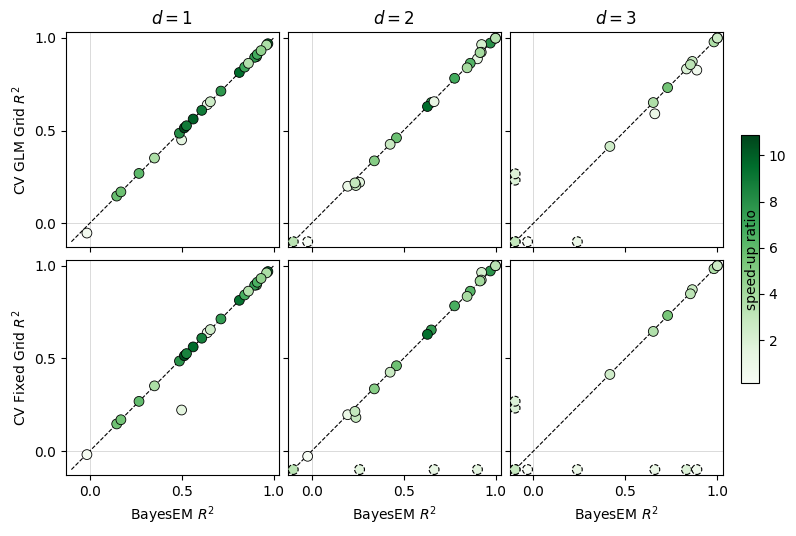

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def make_figure3(exp_d1, exp_d2, exp_d3, output_path=None):
    """2x3 scatter of EM vs CV R² for d=1,2,3. Color = speed-up ratio.

    Top row: CV_glm on y-axis. Bottom row: CV_fix on y-axis.
    Values below CLIP_MIN=-0.1 are clipped and shown with a dashed edge.
    Estimator indices: 0=EM, 1=CV_fix, 2=CV_glm.
    """
    experiments = [exp_d1, exp_d2, exp_d3]
    # (cv_est_idx, cv_label)
    cv_rows = [(2, "CV GLM Grid"), (1, "CV Fixed Grid")]
    CLIP_MIN = -0.1
    PAD      =  0.03

    all_su = [
        np.nanmean(exp.fitting_time_[:, i, 0, cv]) / np.nanmean(exp.fitting_time_[:, i, 0, 0])
        for exp in experiments
        for cv, _ in cv_rows
        for i in range(len(exp.problems))
    ]
    norm = mcolors.Normalize(vmin=min(all_su), vmax=max(all_su))
    cmap = plt.cm.Greens

    fig, axes = plt.subplots(2, 3, figsize=(9, 5.4), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.11, right=0.84, bottom=0.11, top=0.93,
                        hspace=0.06, wspace=0.04)

    for col, exp in enumerate(experiments):
        n_probs = len(exp.problems)
        for row, (cv_idx, cv_label) in enumerate(cv_rows):
            ax = axes[row, col]

            true_em = [np.nanmean(exp.prediction_r2_[:, i, 0, 0]) for i in range(n_probs)]
            true_cv = [np.nanmean(exp.prediction_r2_[:, i, 0, cv_idx]) for i in range(n_probs)]
            su      = [np.nanmean(exp.fitting_time_[:, i, 0, cv_idx])
                       / np.nanmean(exp.fitting_time_[:, i, 0, 0]) for i in range(n_probs)]
            disp_em = [max(CLIP_MIN, x) for x in true_em]
            disp_cv = [max(CLIP_MIN, y) for y in true_cv]
            clipped = [e < CLIP_MIN or c < CLIP_MIN
                       for e, c in zip(true_em, true_cv)]
            colors  = cmap(norm(np.array(su)))

            idx_in  = [i for i, cl in enumerate(clipped) if not cl]
            idx_out = [i for i, cl in enumerate(clipped) if cl]

            if idx_in:
                ax.scatter([disp_em[i] for i in idx_in],
                           [disp_cv[i] for i in idx_in],
                           c=[colors[i] for i in idx_in],
                           s=50, zorder=3, edgecolors="k", linewidths=0.6)
            if idx_out:
                sc = ax.scatter([disp_em[i] for i in idx_out],
                                [disp_cv[i] for i in idx_out],
                                c=[colors[i] for i in idx_out],
                                s=50, zorder=4, edgecolors="k", linewidths=0.8)
                sc.set_linestyle("--")

            ax.plot([CLIP_MIN, 1], [CLIP_MIN, 1], "k--", lw=0.8, zorder=2)
            ax.axhline(0, color="0.8", lw=0.5, zorder=1)
            ax.axvline(0, color="0.8", lw=0.5, zorder=1)
            ax.set_xlim(CLIP_MIN - PAD, 1 + PAD)
            ax.set_ylim(CLIP_MIN - PAD, 1 + PAD)

            if row == 1:
                ax.set_xlabel('BayesEM $R^2$')
                ax.set_xticks([0.0, 0.5, 1.0])
            if col == 0:
                ax.set_ylabel(f'{cv_label} $R^2$')
                ax.set_yticks([0.0, 0.5, 1.0])
            if row == 0:
                ax.set_title(f'$d = {col + 1}$')

    cbar_ax = fig.add_axes([0.86, 0.28, 0.02, 0.46])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.ax.yaxis.set_label_position("right")
    cbar.set_label('speed-up ratio', rotation=90, labelpad=-30)

    if output_path:
        fig.savefig(output_path, bbox_inches='tight')

make_figure3(exp_d1, exp_d2, exp_d3,
             output_path='../output/paper2023_figure3.pdf')

In [14]:
df_csv = df_wide.reset_index()                                                                                                                                                                                                                                                                            
df_csv.columns = [                                                                                                                                                                                                                                                                                          
    col if isinstance(col, str) else                                                                                                                                                                                                                                                                      
    f'd{col[0]}_{col[1]}' if isinstance(col[0], int) else                                                                                                                                                                                                                                                   
    col[0]                                                                                                                                                                                                                                                                                                
    for col in df_csv.columns                                                  
]
df_csv.to_csv('../output/paper2023_table2.csv', index=False)     